# TED Talks — Data Exploration

**Project:** Emotional sentiment analysis of TED Talks across theme groups

**Tianrun's deliverables for April 20:**
1. Load the Kaggle TED dataset into pandas
2. Document all columns
3. Report basic stats (row count, null values, transcript lengths)
4. Produce exploratory summaries for the group

**Dataset source:** https://www.kaggle.com/datasets/rounakbanik/ted-talks

The Kaggle archive contains two CSV files:
- `ted_main.csv` — metadata for each talk (views, comments, tags, speaker, etc.)
- `transcripts.csv` — full transcript text per talk, joined to `ted_main` via the `url` column

Place both files in `../data/` before running this notebook.

## 1. Setup

In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)
sns.set_style('whitegrid')

# Relative paths so the repo runs on anyone's machine
DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

MAIN_PATH = DATA_DIR / 'ted_main.csv'
TRANSCRIPTS_PATH = DATA_DIR / 'transcripts.csv'

print('Main file exists:', MAIN_PATH.exists())
print('Transcripts file exists:', TRANSCRIPTS_PATH.exists())

Main file exists: True
Transcripts file exists: True


## 2. Load the data

In [2]:
ted_main = pd.read_csv(MAIN_PATH)
transcripts = pd.read_csv(TRANSCRIPTS_PATH)

print(f'ted_main:    {ted_main.shape[0]:>5,} rows x {ted_main.shape[1]:>2} cols')
print(f'transcripts: {transcripts.shape[0]:>5,} rows x {transcripts.shape[1]:>2} cols')

ted_main:    2,550 rows x 17 cols
transcripts: 2,467 rows x  2 cols


In [3]:
ted_main.head(3)

,comments,description,duration,event,film_date,languages,main_speaker,name,num_speaker,published_date,ratings,related_talks,speaker_occupation,tags,title,url,views
0,4553,Sir Ken Robinson makes an entertaining and profoundly moving case for creati...,1164,TED2006,1140825600,60,Ken Robinson,Ken Robinson: Do schools kill creativity?,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 19645}, {'id': 1, 'name': 'Beautiful', ...","[{'id': 865, 'hero': 'https://pe.tedcdn.com/images/ted/172559_800x600.jpg', ...",Author/educator,"['children', 'creativity', 'culture', 'dance', 'education', 'parenting', 'te...",Do schools kill creativity?,https://www.ted.com/talks/ken_robinson_says_schools_kill_creativity\n,47227110
1,265,"With the same humor and humanity he exuded in ""An Inconvenient Truth,"" Al Go...",977,TED2006,1140825600,43,Al Gore,Al Gore: Averting the climate crisis,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 544}, {'id': 3, 'name': 'Courageous', '...","[{'id': 243, 'hero': 'https://pe.tedcdn.com/images/ted/566c14767bd62c5ff760e...",Climate advocate,"['alternative energy', 'cars', 'climate change', 'culture', 'environment', '...",Averting the climate crisis,https://www.ted.com/talks/al_gore_on_averting_climate_crisis\n,3200520
2,124,New York Times columnist David Pogue takes aim at technology’s worst interfa...,1286,TED2006,1140739200,26,David Pogue,David Pogue: Simplicity sells,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 964}, {'id': 3, 'name': 'Courageous', '...","[{'id': 1725, 'hero': 'https://pe.tedcdn.com/images/ted/b7f415a054cc0a2bfdd9...",Technology columnist,"['computers', 'entertainment', 'interface design', 'media', 'music', 'perfor...",Simplicity sells,https://www.ted.com/talks/david_pogue_says_simplicity_sells\n,1636292


In [4]:
transcripts.head(2)

,transcript,url
0,"Good morning. How are you?(Laughter)It's been great, hasn't it? I've been bl...",https://www.ted.com/talks/ken_robinson_says_schools_kill_creativity\n
1,"Thank you so much, Chris. And it's truly a great honor to have the opportuni...",https://www.ted.com/talks/al_gore_on_averting_climate_crisis\n


## 3. Column documentation

Below is the expected schema for the Kaggle dataset. We'll also auto-generate a data dictionary from the loaded files.

### `ted_main.csv`
| Column | Type | Description |
|---|---|---|
| `name` | str | Full title of the talk, often `Speaker: Title` |
| `title` | str | Talk title |
| `description` | str | Short blurb about the talk |
| `main_speaker` | str | Primary speaker name |
| `speaker_occupation` | str | Speaker's occupation |
| `num_speaker` | int | Number of speakers |
| `duration` | int | Talk duration in seconds |
| `event` | str | TED event where the talk was given (e.g. TED2014) |
| `film_date` | int | Unix timestamp of filming date |
| `published_date` | int | Unix timestamp of publication date on ted.com |
| `comments` | int | Number of first-level comments on ted.com |
| `tags` | str (list) | Stringified list of topic tags — **key column for our theme groups** |
| `languages` | int | Number of languages the talk is available in |
| `ratings` | str (list of dicts) | Stringified list of rating categories with counts (Inspiring, Funny, etc.) |
| `related_talks` | str (list of dicts) | Stringified list of related talks |
| `url` | str | Canonical URL on ted.com — **join key with transcripts** |
| `views` | int | View count on ted.com (note: *not* YouTube views) |

### `transcripts.csv`
| Column | Type | Description |
|---|---|---|
| `transcript` | str | Full transcript of the talk |
| `url` | str | Canonical URL — join key with `ted_main` |

> **Note for our research question:** The dataset reports `views` from ted.com, not YouTube. If we strictly need YouTube views/likes/comments we'd need to scrape them separately. For Update 1 we'll treat `views`, `comments`, and `languages` as engagement proxies and flag this in the report.

In [5]:
# Auto-generated data dictionary
def data_dictionary(df, name):
    rows = []
    for col in df.columns:
        s = df[col]
        rows.append({
            'column': col,
            'dtype': str(s.dtype),
            'non_null': s.notna().sum(),
            'null': s.isna().sum(),
            'null_pct': round(s.isna().mean() * 100, 2),
            'unique': s.nunique(dropna=True),
            'example': s.dropna().iloc[0] if s.notna().any() else None,
        })
    dd = pd.DataFrame(rows)
    dd['example'] = dd['example'].astype(str).str.slice(0, 60)
    print(f'\n=== Data dictionary: {name} ===')
    return dd

dd_main = data_dictionary(ted_main, 'ted_main.csv')
dd_main


=== Data dictionary: ted_main.csv ===


,column,dtype,non_null,null,null_pct,unique,example
0,comments,int64,2550,0,0.00,559,4553
1,description,str,2550,0,0.00,2550,Sir Ken Robinson makes an entertaining and profoundly moving
2,duration,int64,2550,0,0.00,1083,1164
3,event,str,2550,0,0.00,355,TED2006
4,film_date,int64,2550,0,0.00,735,1140825600
5,languages,int64,2550,0,0.00,66,60
6,main_speaker,str,2550,0,0.00,2156,Ken Robinson
7,name,str,2550,0,0.00,2550,Ken Robinson: Do schools kill creativity?
8,num_speaker,int64,2550,0,0.00,5,1
9,published_date,int64,2550,0,0.00,2490,1151367060


In [6]:
dd_transcripts = data_dictionary(transcripts, 'transcripts.csv')
dd_transcripts


=== Data dictionary: transcripts.csv ===


,column,dtype,non_null,null,null_pct,unique,example
0,transcript,str,2467,0,0.0,2464,"Good morning. How are you?(Laughter)It's been great, hasn't"
1,url,str,2467,0,0.0,2464,https://www.ted.com/talks/ken_robinson_says_schools_kill_cre


In [7]:
# Save the data dictionaries for the repo / report appendix
dd_main.to_csv(OUTPUT_DIR / 'data_dictionary_ted_main.csv', index=False)
dd_transcripts.to_csv(OUTPUT_DIR / 'data_dictionary_transcripts.csv', index=False)
print('Saved data dictionaries to ../outputs/')

Saved data dictionaries to ../outputs/


## 4. Null value check

In [8]:
print('Nulls in ted_main:')
print(ted_main.isna().sum().sort_values(ascending=False))
print('\nNulls in transcripts:')
print(transcripts.isna().sum().sort_values(ascending=False))

Nulls in ted_main:
speaker_occupation    6
comments              0
description           0
event                 0
duration              0
languages             0
main_speaker          0
name                  0
film_date             0
num_speaker           0
published_date        0
ratings               0
related_talks         0
tags                  0
title                 0
url                   0
views                 0
dtype: int64

Nulls in transcripts:
transcript    0
url           0
dtype: int64


## 5. Merge metadata with transcripts

Not every talk in `ted_main` has a transcript (talks without transcripts were excluded from Kaggle's scrape). We use an **inner join on `url`** to keep only talks we can analyse textually.

In [9]:
df = ted_main.merge(transcripts, on='url', how='inner')

print(f'ted_main rows:       {len(ted_main):,}')
print(f'transcripts rows:    {len(transcripts):,}')
print(f'Merged (inner) rows: {len(df):,}')
print(f'Dropped from ted_main: {len(ted_main) - len(df):,} (no transcript available)')

ted_main rows:       2,550
transcripts rows:    2,467
Merged (inner) rows: 2,467
Dropped from ted_main: 83 (no transcript available)


In [10]:
# Check for duplicates on the join key
dup_urls_main = ted_main['url'].duplicated().sum()
dup_urls_tr = transcripts['url'].duplicated().sum()
dup_urls_merged = df['url'].duplicated().sum()
print(f'Duplicate URLs in ted_main:    {dup_urls_main}')
print(f'Duplicate URLs in transcripts: {dup_urls_tr}')
print(f'Duplicate URLs in merged:      {dup_urls_merged}')

Duplicate URLs in ted_main:    0
Duplicate URLs in transcripts: 3
Duplicate URLs in merged:      3


## 6. Transcript length statistics

We measure length two ways:
- **Character count** (`transcript_len_chars`) — raw length
- **Word count** (`transcript_len_words`) — whitespace-tokenised, closer to what we'll analyse downstream

In [11]:
df['transcript_len_chars'] = df['transcript'].str.len()
df['transcript_len_words'] = df['transcript'].str.split().str.len()

len_stats = df[['transcript_len_chars', 'transcript_len_words']].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]
).round(0)
len_stats

,transcript_len_chars,transcript_len_words
count,2467.0,2467.0
mean,11439.0,2040.0
std,5292.0,956.0
min,17.0,1.0
10%,4399.0,780.0
25%,7568.0,1332.0
50%,11539.0,2028.0
75%,15119.0,2707.0
90%,17854.0,3190.0
99%,24063.0,4387.0


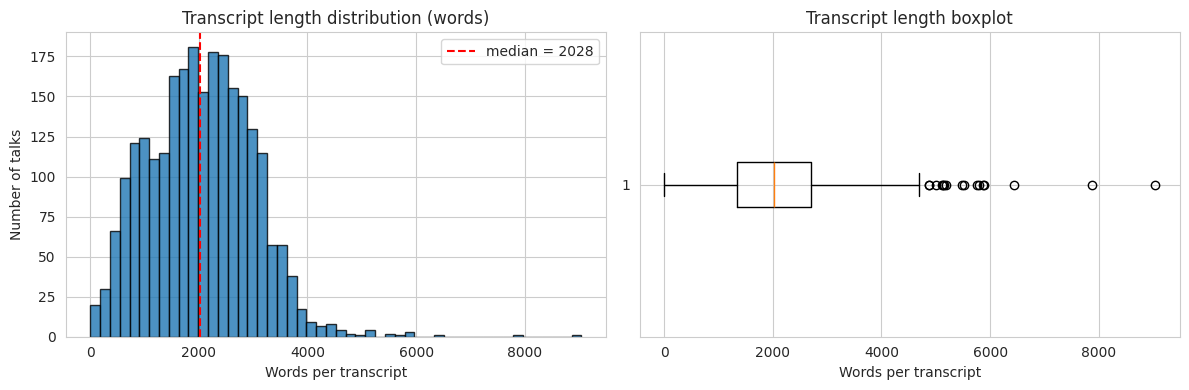

In [12]:
# Plot the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['transcript_len_words'], bins=50, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Words per transcript')
axes[0].set_ylabel('Number of talks')
axes[0].set_title('Transcript length distribution (words)')
axes[0].axvline(df['transcript_len_words'].median(), color='red', linestyle='--',
                label=f"median = {int(df['transcript_len_words'].median())}")
axes[0].legend()

axes[1].boxplot(df['transcript_len_words'], vert=False)
axes[1].set_xlabel('Words per transcript')
axes[1].set_title('Transcript length boxplot')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'transcript_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Flag outliers for the group to discuss (very short = announcements/intros?)
print('Shortest 5 transcripts:')
print(df.nsmallest(5, 'transcript_len_words')[['title', 'main_speaker', 'duration', 'transcript_len_words']].to_string(index=False))
print('\nLongest 5 transcripts:')
print(df.nlargest(5, 'transcript_len_words')[['title', 'main_speaker', 'duration', 'transcript_len_words']].to_string(index=False))

Shortest 5 transcripts:
                                          title                main_speaker  duration  transcript_len_words
                                 My magic moves               Kenichi Ebina       212                     1
             On violin and cello, "Passacaglia" Robert Gupta + Joshua Roman       561                     1
                             Dancing with light             Quixotic Fusion       742                     1
A dance in a hurricane of paper, wind and light               Aakash Odedra       590                     1
An 11-year-old prodigy performs old-school jazz              Joey Alexander       388                     2

Longest 5 transcripts:
                                               title                   main_speaker  duration  transcript_len_words
 Nationalism vs. globalism: the new political divide              Yuval Noah Harari      3608                  9044
Political common ground in a polarized United States Gretchen Carlson, D

## 7. Tag analysis (preview for Person 2/3)

The `tags` column is stored as a stringified Python list. We'll parse it and count frequencies. It helps prepare for defining the **theme groups** (Education, Psychology, Society, Environment, Business) next week.

In [14]:
# Parse tags safely
def parse_tags(val):
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return []

df['tags_list'] = df['tags'].apply(parse_tags)
df['num_tags'] = df['tags_list'].apply(len)

print('Tags per talk:')
print(df['num_tags'].describe().round(2))
print(f"\nTalks with zero tags: {(df['num_tags'] == 0).sum()}")

Tags per talk:
count    2467.00
mean        7.55
std         4.33
min         1.00
25%         5.00
50%         6.00
75%         9.00
max        32.00
Name: num_tags, dtype: float64

Talks with zero tags: 0


In [15]:
# Flatten tags and count frequency
all_tags = [tag for tags in df['tags_list'] for tag in tags]
tag_counts = pd.Series(all_tags).value_counts()

print(f'Total unique tags: {len(tag_counts):,}')
print(f'Total tag applications: {len(all_tags):,}')
print('\nTop 30 tags:')
print(tag_counts.head(30))

Total unique tags: 416
Total tag applications: 18,634

Top 30 tags:
technology       712
science          548
global issues    490
culture          476
TEDx             418
design           408
business         338
entertainment    287
health           234
innovation       224
society          223
art              218
social change    216
future           194
communication    190
creativity       182
biology          182
humanity         177
collaboration    169
environment      162
economics        160
medicine         160
activism         155
brain            153
education        147
community        147
history          142
TED Fellows      141
children         140
invention        139
Name: count, dtype: int64


In [16]:
# Save tag counts for Person 1's week-2 deliverable (theme group definition)
tag_counts.to_csv(OUTPUT_DIR / 'tag_frequencies.csv', header=['count'])
print('Saved tag frequencies to ../outputs/tag_frequencies.csv')

Saved tag frequencies to ../outputs/tag_frequencies.csv


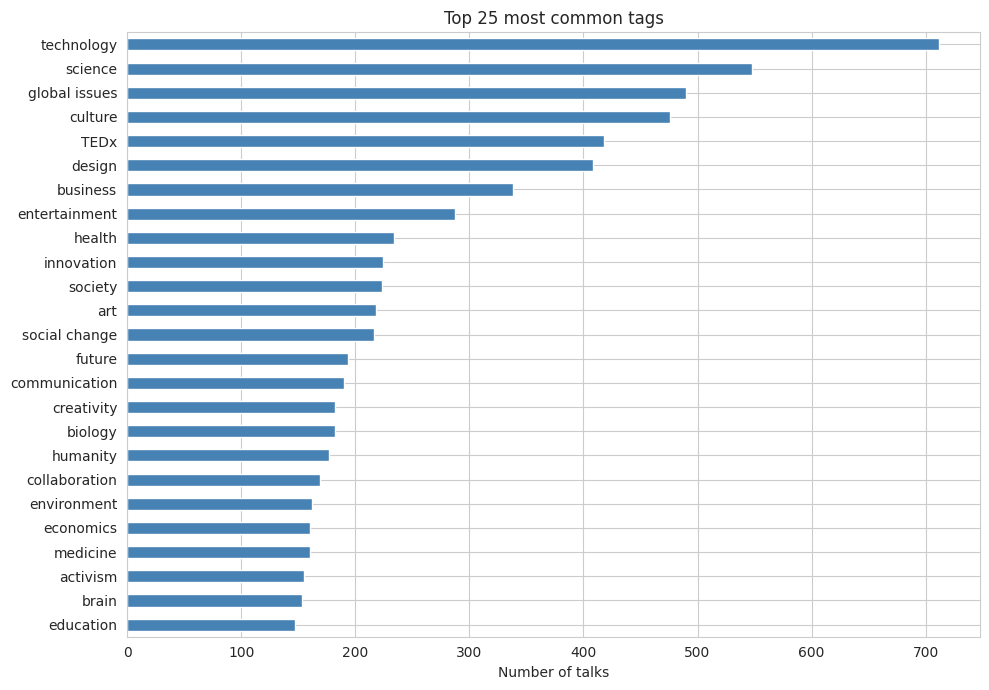

In [17]:
# Visualise top 25
fig, ax = plt.subplots(figsize=(10, 7))
tag_counts.head(25).iloc[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of talks')
ax.set_title('Top 25 most common tags')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_tags.png', dpi=150, bbox_inches='tight')
plt.show()

### Quick peek: how many talks match our proposed theme groups?

This is a first, very rough look using single tags. My goal is to define the full tag sets per theme group (e.g. *business* might include `business`, `economics`, `entrepreneur`, `finance`, ...).

In [18]:
proposed_themes = ['education', 'psychology', 'society', 'environment', 'business']
print('Talks directly tagged with a proposed theme name:')
for theme in proposed_themes:
    n = df['tags_list'].apply(lambda tags: theme in tags).sum()
    print(f'  {theme:<14} {n:>4} talks')
print('\nNote: these are first-pass counts using a single exact-match tag. '
      'Final theme groups should bundle multiple related tags.')

Talks directly tagged with a proposed theme name:
  education       147 talks
  psychology      117 talks
  society         223 talks
  environment     162 talks
  business        338 talks

Note: these are first-pass counts using a single exact-match tag. Final theme groups should bundle multiple related tags.


## 8. Engagement metrics sanity check

Quick look at the engagement columns we'll use as outcome variables (`views`, `comments`, `languages`).

In [19]:
engagement_cols = ['views', 'comments', 'languages', 'duration']
df[engagement_cols].describe().round(1)

,views,comments,languages,duration
count,2467.0,2467.0,2467.0,2467.0
mean,1740295.4,192.6,28.3,821.8
std,2527086.2,284.8,8.2,334.1
min,155895.0,2.0,1.0,135.0
25%,787578.5,63.0,23.0,582.0
50%,1149090.0,117.0,28.0,852.0
75%,1736256.0,222.5,33.0,1047.0
max,47227110.0,6404.0,72.0,3608.0


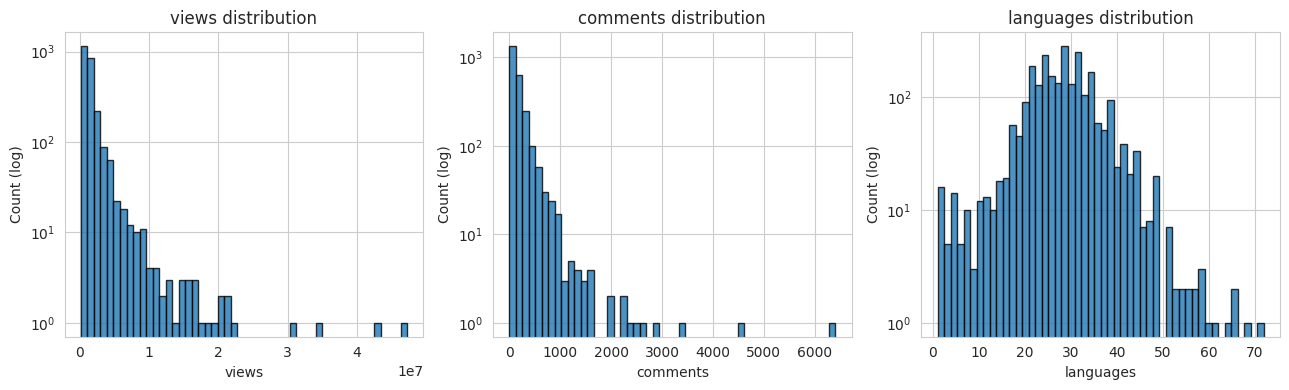

In [20]:
# These are very right-skewed, which matters for the stats tests in the later analysis
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ['views', 'comments', 'languages']):
    ax.hist(df[col], bins=50, edgecolor='black', alpha=0.8)
    ax.set_yscale('log')
    ax.set_xlabel(col)
    ax.set_ylabel('Count (log)')
    ax.set_title(f'{col} distribution')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'engagement_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save the clean base dataset for the team

This merged frame is the starting point for preprocessing.

In [21]:
# Drop the parsed list column before saving (CSV can't store lists cleanly; keep `tags` as original string)
out_cols = [c for c in df.columns if c != 'tags_list']
out_path = DATA_DIR / 'ted_merged.csv'
df[out_cols].to_csv(out_path, index=False)
print(f'Saved merged dataset -> {out_path}   ({len(df):,} rows)')

Saved merged dataset -> ../data/ted_merged.csv   (2,467 rows)


## 10. Summary — what I'm reporting to the group

Run the cell below to produce the short summary to drop into our first GitHub issue.

In [22]:
summary = f"""
# Data Exploration Summary

## Files loaded
- ted_main.csv:    {len(ted_main):,} rows, {ted_main.shape[1]} columns
- transcripts.csv: {len(transcripts):,} rows, {transcripts.shape[1]} columns
- Merged (inner on url): {len(df):,} rows -> this is our working dataset
- Talks dropped (no transcript): {len(ted_main) - len(df):,}

## Null values
- ted_main: {ted_main.isna().sum().sum()} total nulls (mostly in speaker_occupation)
- transcripts: {transcripts.isna().sum().sum()} total nulls
- After merge: {df[[c for c in df.columns if c != 'tags_list']].isna().sum().sum()} total nulls

## Transcript lengths (words)
- min:    {int(df['transcript_len_words'].min()):>6,}
- median: {int(df['transcript_len_words'].median()):>6,}
- mean:   {int(df['transcript_len_words'].mean()):>6,}
- max:    {int(df['transcript_len_words'].max()):>6,}

## Tags
- Unique tags: {len(tag_counts):,}
- Tags per talk (median): {int(df['num_tags'].median())}
- Top 5 tags: {', '.join(tag_counts.head(5).index.tolist())}

## Flags for the group to discuss
1. The `views` column is from ted.com, NOT YouTube. Our research question mentions
   YouTube views/likes/comments specifically - we should decide whether to (a) scrape
   YouTube separately or (b) reframe to use ted.com engagement and flag this in the report.
2. Engagement metrics are very right-skewed - we'll need log transforms or non-parametric
   tests in the statistical analysis.
3. Some transcripts are <100 words (likely intros/performances) - we may want to filter
   these out before sentiment analysis.
4. The proposed theme groups need tag bundles, not single tags. I'll lead that for next week.
"""
print(summary)

with open(OUTPUT_DIR / 'week1_summary.md', 'w') as f:
    f.write(summary)
print('Summary saved to ../outputs/week1_summary.md')


# Data Exploration Summary

## Files loaded
- ted_main.csv:    2,550 rows, 17 columns
- transcripts.csv: 2,467 rows, 2 columns
- Merged (inner on url): 2,467 rows -> this is our working dataset
- Talks dropped (no transcript): 83

## Null values
- ted_main: 6 total nulls (mostly in speaker_occupation)
- transcripts: 0 total nulls
- After merge: 6 total nulls

## Transcript lengths (words)
- min:         1
- median:  2,028
- mean:    2,040
- max:     9,044

## Tags
- Unique tags: 416
- Tags per talk (median): 6
- Top 5 tags: technology, science, global issues, culture, TEDx

## Flags for the group to discuss
1. The `views` column is from ted.com, NOT YouTube. Our research question mentions
   YouTube views/likes/comments specifically - we should decide whether to (a) scrape
   YouTube separately or (b) reframe to use ted.com engagement and flag this in the report.
2. Engagement metrics are very right-skewed - we'll need log transforms or non-parametric
   tests in the statistical analy